In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("cleaned_Beer_data.csv")
df.head()

,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,...,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",-0.481696,0.28848,0.515791,-0.337764,-0.544620,...,-0.171238,0.528815,-0.435553,0.893892,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",0.264397,0.28848,0.515791,-0.433834,0.419002,...,-0.449949,-0.194896,-0.267152,0.217253,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,-0.599501,0.28848,0.515791,-0.241694,-0.351895,...,-0.883498,0.430127,-0.603954,-0.334083,3.409814,3.667109,3.600796,3.631300,3.830239,377
3,Doppelsticke,Altbier,Uerige Obergärige Hausbrauerei GmbH / Zum Uerige,Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...,Notes:,0.774882,0.28848,0.515791,-0.337764,0.341912,...,0.324247,-0.030416,-0.098752,1.094378,4.148098,4.033967,4.150815,4.205163,4.005435,368
4,Sleigh'r Dark Doüble Alt Ale,Altbier,Ninkasi Brewing Company,Ninkasi Brewing Company Sleigh'r Dark Doüble A...,Notes:Called 'Dark Double Alt' on the label.Se...,0.264397,0.28848,0.515791,0.815081,0.187733,...,-0.852530,0.331439,0.069649,0.492921,3.625000,3.973958,3.734375,3.765625,3.817708,96


In [6]:
# Beer specification variables
specific_cols = ['ABV', 'Min IBU', 'Max IBU']

profile_features = [
    'Astringency', 'Body', 'Alcohol',
    'Bitter', 'Sweet', 'Sour', 'Salty',
    'Fruits', 'Hoppy', 'Spices', 'Malty'
]

# Main variables used to check clusterability
cluster_features = specific_cols + profile_features

X = df[cluster_features].copy()

X = X.select_dtypes(include=[np.number])
X.head()

,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
0,-0.481696,0.28848,0.515791,-0.337764,-0.544620,-0.464895,0.412438,0.458897,-0.004066,-0.477041,-0.171238,0.528815,-0.435553,0.893892
1,0.264397,0.28848,0.515791,-0.433834,0.419002,0.054477,-0.130468,-0.095428,-0.479264,-0.477041,-0.449949,-0.194896,-0.267152,0.217253
2,-0.599501,0.28848,0.515791,-0.241694,-0.351895,-0.638019,0.218543,-0.445528,-0.619028,-0.477041,-0.883498,0.430127,-0.603954,-0.334083
3,0.774882,0.28848,0.515791,-0.337764,0.341912,0.804681,0.412438,1.246621,-0.423358,-0.008068,0.324247,-0.030416,-0.098752,1.094378
4,0.264397,0.28848,0.515791,0.815081,0.187733,0.516141,0.296101,-0.387178,-0.674933,-0.008068,-0.852530,0.331439,0.069649,0.492921


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(3197, 14)

In [9]:
perplexity_values = [5, 10, 20, 30, 40, 50]
random_states = [33, 437]

tsne_results = {}

for perp in perplexity_values:
    for rs in random_states:
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            random_state=rs,
            init="random",
            learning_rate="auto",
            max_iter=1000
        )
        
        tsne_embedding = tsne.fit_transform(X_scaled)
        
        temp_df = df.copy()
        temp_df["tsne_x"] = tsne_embedding[:, 0]
        temp_df["tsne_y"] = tsne_embedding[:, 1]
        
        tsne_results[(perp, rs)] = temp_df

# KMeans Clustering

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
kmeans_cols = [
    'ABV', 'Min IBU', 'Max IBU',
    'Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet',
    'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty',
]

X = df[kmeans_cols]

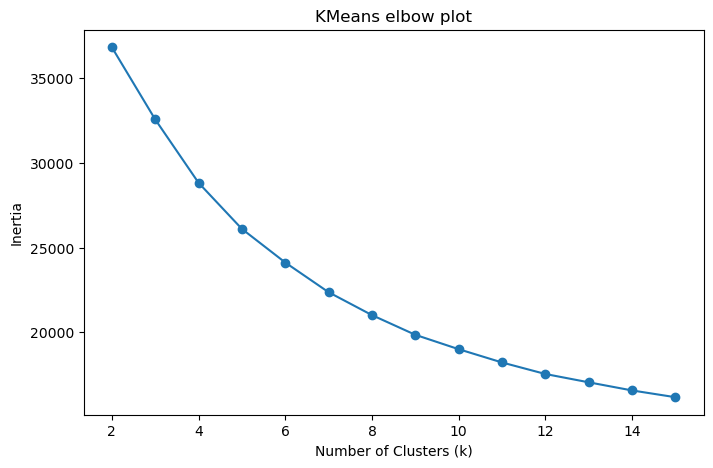

In [17]:
inertias = []

k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=437, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize = (8,5))
plt.plot(k_values, inertias, marker = "o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans elbow plot")
plt.show()

# Average Silhouette Score Plot

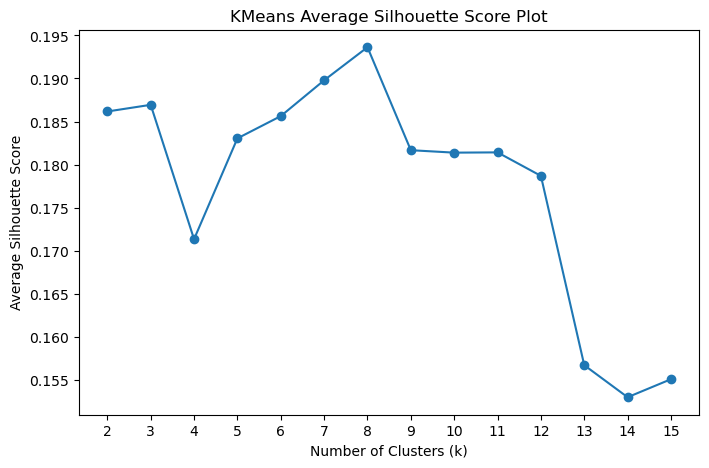

In [18]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_values = range(2,16)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state=437, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("KMeans Average Silhouette Score Plot")
plt.xticks(k_values)
plt.show()

- The elbow plot shows a steady decline in inertia as the number of clusters increases, indicating that the beer flavor-profile dataset contains meaningful clustering structure rather than being completely random. The largest reductions occur between k = 2 and approximately k = 8, after which the curve becomes more gradual. This suggests that additional clusters beyond this range provide diminishing returns in reducing within-cluster variation. Based on the elbow plot, values between k = 6 and k = 8 appear to be reasonable candidate solutions for further evaluation.

- The average silhouette score plot provides additional evidence for selecting the number of clusters. While the scores are relatively modest overall, the highest value occurs at k = 8, indicating that this solution provides the best balance of within-cluster cohesion and between-cluster separation among the tested KMeans models. Scores for k = 7 and several smaller values of k are also competitive, suggesting that the dataset may contain both broader beer categories and smaller subgroups. Combining the elbow and silhouette evidence, k = 8 appears to be a strong candidate for the final KMeans clustering, with k = 7 as another reasonable alternative.

# t-SNE Plot Corroboration

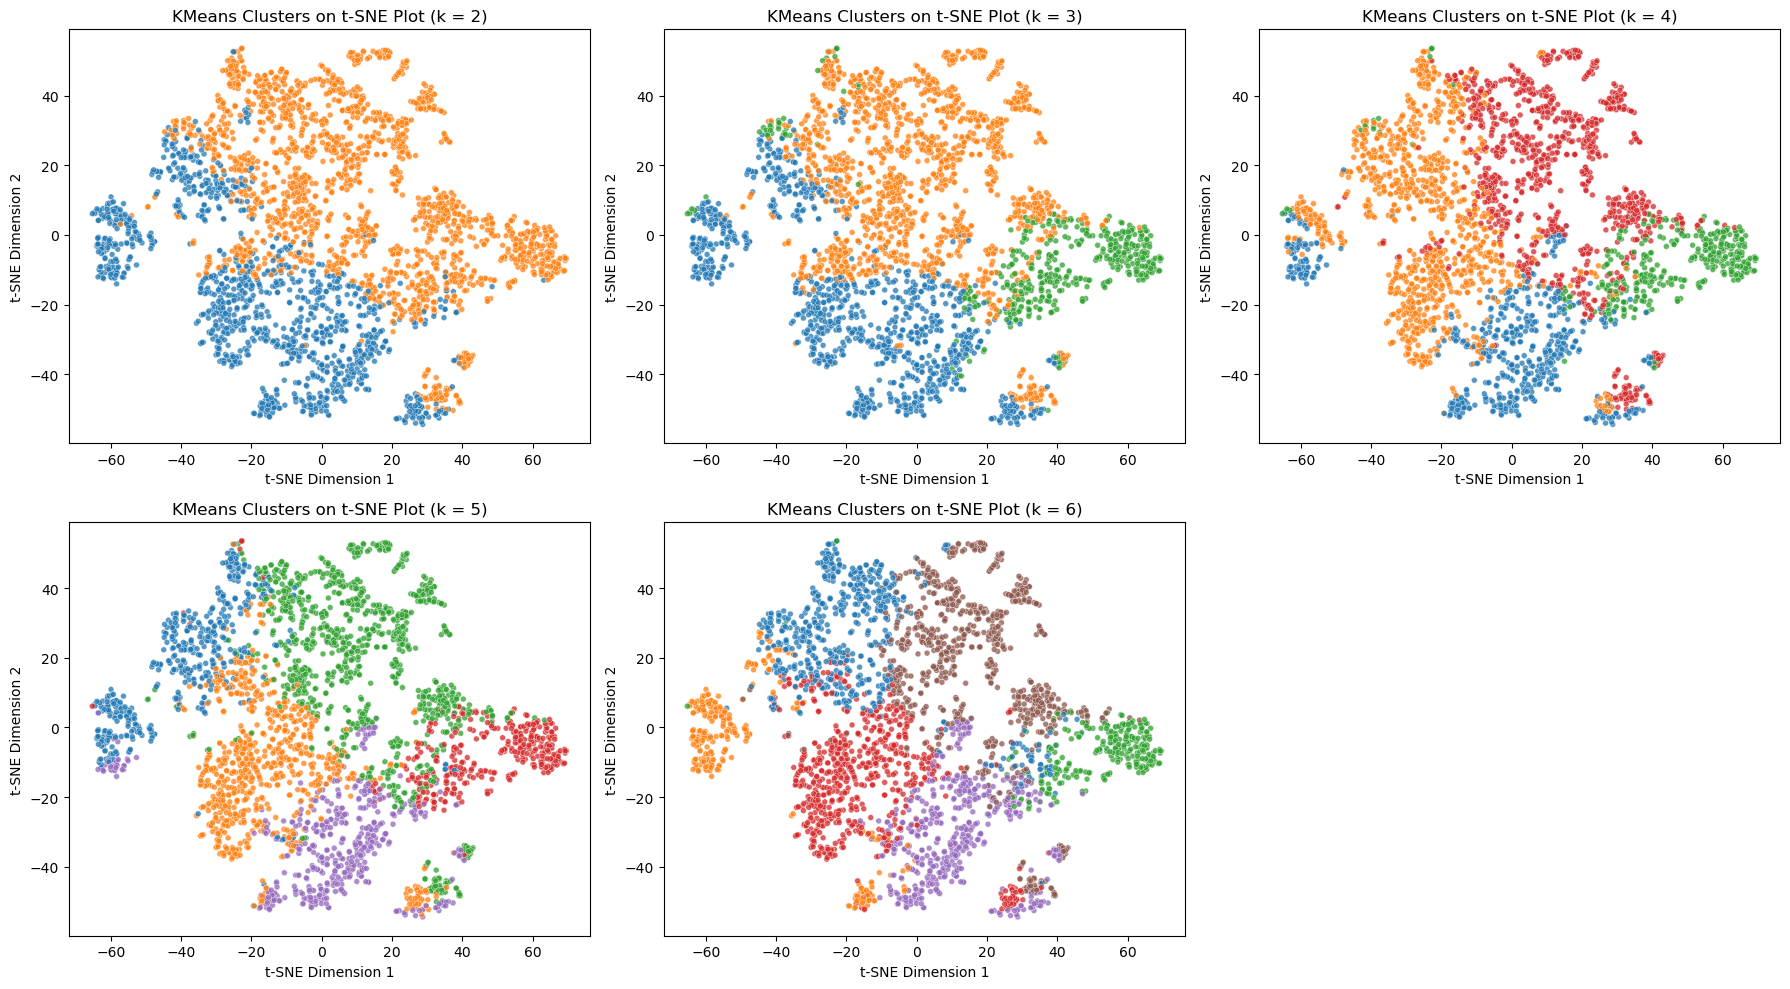

In [19]:
representative_perplexity = 30
representative_random_state = 33

df_tsne_kmeans = tsne_results[
    (representative_perplexity, representative_random_state)
].copy()

k_candidates = [2,3,4,5,6]
for k in k_candidates:
    kmeans = KMeans(n_clusters= k, random_state = 437, n_init=10)
    df_tsne_kmeans[f"kmeans_k{k}"] = kmeans.fit_predict(X)

fig, axes = plt.subplots(2,3, figsize = (18,10))
axes = axes.flatten()

for i,k in enumerate(k_candidates):
    sns.scatterplot(data = df_tsne_kmeans, x="tsne_x",
        y="tsne_y",
        hue=f"kmeans_k{k}",
        palette="tab10",
        s=18,
        alpha=0.75,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(f"KMeans Clusters on t-SNE Plot (k = {k})")
    axes[i].set_xlabel("t-SNE Dimension 1")
    axes[i].set_ylabel("t-SNE Dimension 2")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

    



- Because these t-SNE plots were created using only intrinsic beer profile variables and excluding review variables, the clustering results are especially meaningful for identifying inherent product-based structure rather than consumer-rating driven groupings. This means the observed clusters are more likely to reflect genuine differences in alcohol content, bitterness, sweetness, fruitiness, hoppiness, maltiness, and other tasting characteristics of the beers themselves.

- Under this framework, the t-SNE corroboration provides stronger evidence that the KMeans clusters are capturing natural beer style segments rather than simply separating beers based on popularity or review scores. Smaller values such as k = 2 and k = 3 still appear to merge several visibly distinct flavor-profile regions, suggesting under-segmentation. In contrast, k = 5 and k = 6 align more closely with multiple separated regions in the t-SNE map while maintaining interpretable cluster structure. Therefore, these solutions provide stronger evidence of identifying inherent beer profile clusters that are consistent with the research goal of uncovering naturally occurring groups in the dataset.

# Cluster-Sorted Similarity Matrix

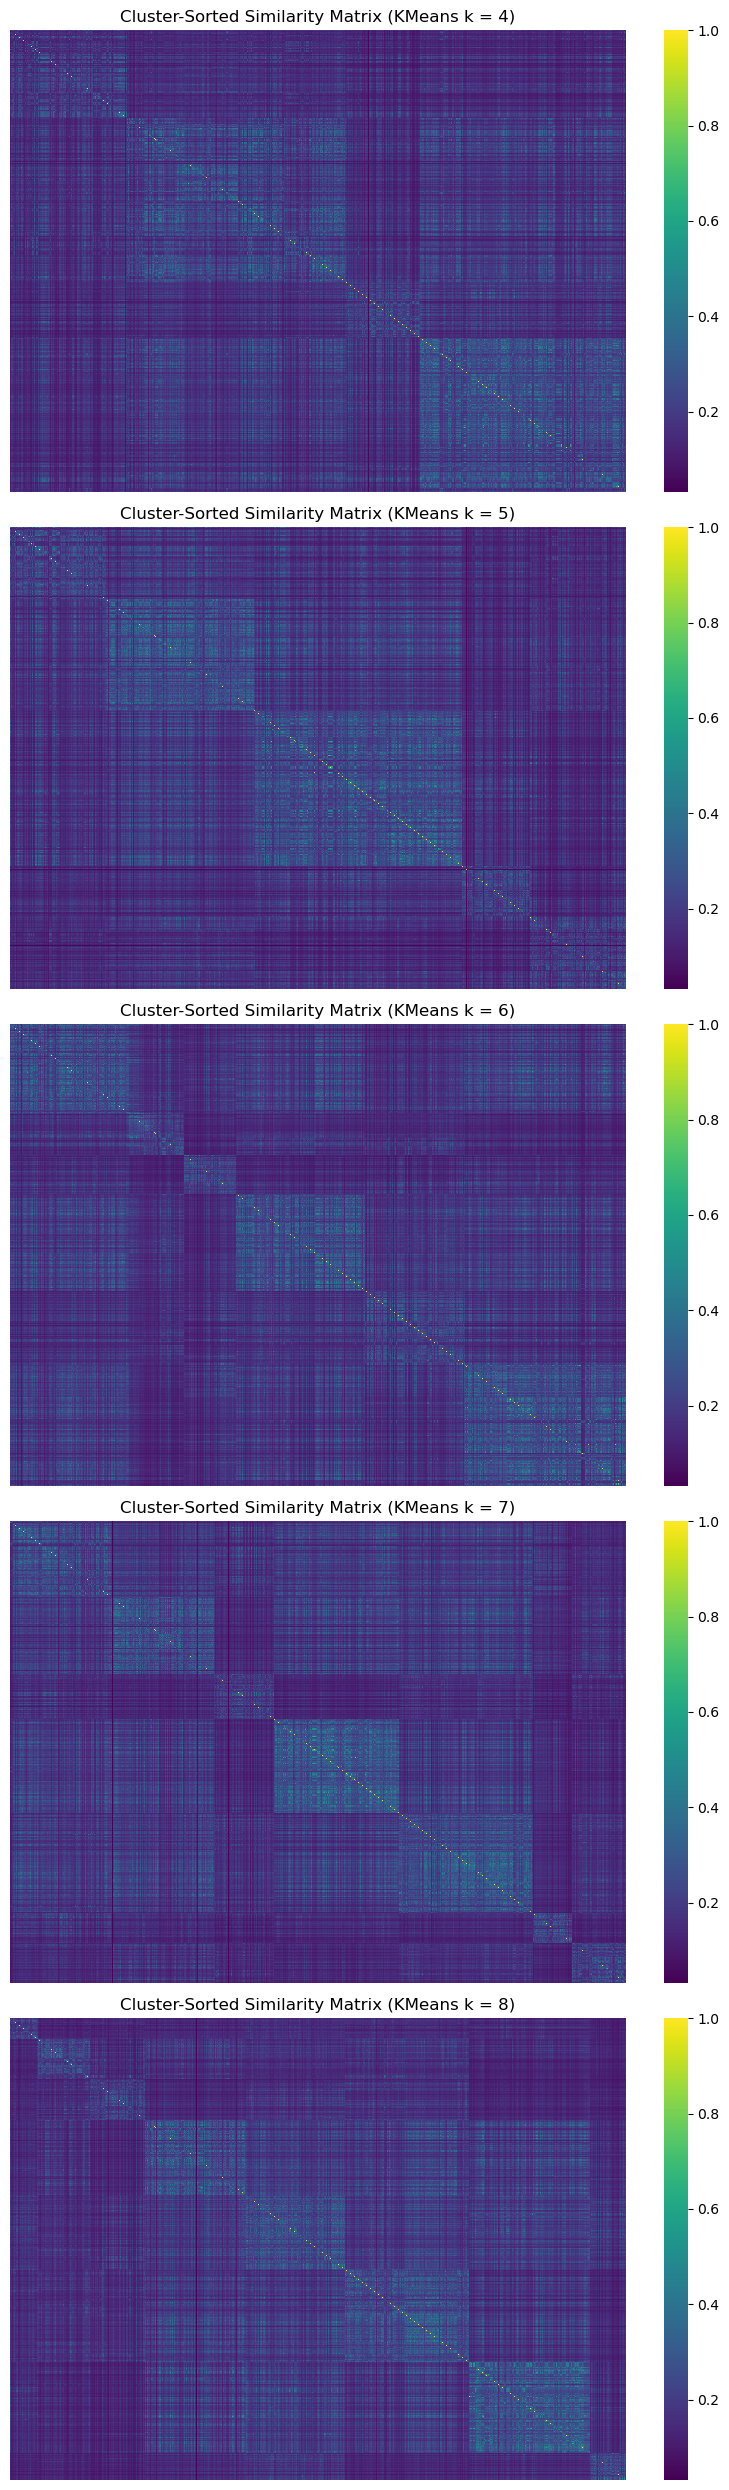

In [20]:
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import squareform

dist_matrix = euclidean_distances(X)

sim_matrix = 1 / (1 + dist_matrix)

k_candidates = [4,5,6,7,8]

fig, axes = plt.subplots(len(k_candidates), 1, figsize=(8, 5 * len(k_candidates)))

for i, k in enumerate(k_candidates):
    
    kmeans = KMeans(n_clusters=k, random_state=437, n_init=10)
    labels = kmeans.fit_predict(X)
    
    sorted_index = np.argsort(labels)
    
    sorted_sim = sim_matrix[sorted_index, :][:, sorted_index]
    
    sns.heatmap(
        sorted_sim,
        cmap="viridis",
        xticklabels=False,
        yticklabels=False,
        cbar=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Cluster-Sorted Similarity Matrix (KMeans k = {k})")

plt.tight_layout()
plt.show()

- The cluster-sorted similarity matrices provide visual evidence of cluster cohesion and separation. Stronger clustering solutions are expected to show brighter block-diagonal structures, indicating high within-cluster similarity, along with darker off-diagonal regions, indicating lower similarity between clusters.

- For smaller values such as k = 4, the block structure is present but relatively broad, suggesting that several distinct beer groups may still be merged together. The solutions for k = 5 and k = 6 show clearer diagonal blocks and stronger separation between clusters, indicating improved clustering quality. In particular, k = 6 appears to provide a strong balance between cohesive within-cluster similarity and meaningful separation across groups.

- For larger values such as k = 7 and k = 8, the matrices continue to show clear structure, although some smaller clusters begin to emerge. The k = 8 solution remains visually strong and is also supported by the highest silhouette score. Overall, the similarity matrices suggest that k = 6 and k = 8 provide the strongest clustering evidence among the tested KMeans solutions.

# Outliers and Noise Handling Evaluation

- The beer dataset likely contains some outliers or noisy observations, such as highly unusual beers with extreme alcohol content, bitterness levels, or uncommon flavor profiles. In the t-SNE visualizations, several small isolated regions suggest that some beers may behave differently from the majority of the dataset.

- KMeans does not explicitly detect noise points, since every observation must be assigned to a cluster. As a result, potential outliers are forced into the nearest cluster, which may slightly reduce cluster cohesion or distort cluster centers. This is an important limitation compared with density-based methods such as DBSCAN.

- However, for the goals of this project, many isolated observations may represent niche beer styles rather than meaningless noise. In that sense, KMeans can still be useful because it groups these beers into smaller segments instead of discarding them. Therefore, KMeans handled unusual observations reasonably well for market segmentation purposes, although it is not ideal for true outlier detection.

# Select Best Clustering

- Based on the parameter tuning results, the KMeans solutions with k = 6 and k = 8 provide the strongest overall evidence among the tested models. These clusterings performed well across multiple evaluation criteria, including the elbow plot, average silhouette scores, t-SNE corroboration, and cluster-sorted similarity matrices.

- The k = 6 solution appears to provide the best overall balance between interpretability and clustering quality. In the t-SNE visualizations, it aligns well with several naturally separated beer regions while avoiding excessive fragmentation. Its similarity matrix also shows strong within-cluster cohesion and clear between-cluster separation. This suggests that k = 6 captures the major inherent beer profile groups while still remaining easy to interpret.

- The k = 8 solution provides a more detailed segmentation and achieved the highest silhouette score, indicating strong cohesion and separation statistically. It may capture additional sub-cluster structure within larger beer groups, making it highly informative for finer market segmentation.

- Overall, if the primary goal is to identify broad inherent clusters with clear interpretation, k = 6 is the strongest candidate. If the goal is more detailed segmentation and discovering smaller niche groups, k = 8 is also a strong option. Both solutions are well aligned with the research objective of uncovering naturally occurring beer profile clusters.

# Technique Shortcoming

- The beer dataset has several characteristics that may limit the usefulness of standard clustering diagnostics. Beer styles and flavor profiles often exist on a continuum rather than as perfectly separated groups. Many beers may share overlapping characteristics such as bitterness, sweetness, hoppiness, maltiness, or alcohol strength, which creates gradual transitions between clusters rather than sharp boundaries.

- For the elbow plot, this means there may not be one clear correct number of clusters. If the dataset contains both broad beer categories and smaller subgroups within them, the elbow method may only detect major divisions and fail to identify meaningful sub-cluster structure. As a result, multiple values of k may appear reasonable.

- For the average silhouette score, the clustering with the highest score may not necessarily identify all inherent clusters. Silhouette scores tend to favor compact and well-separated groups. In this dataset, a simpler clustering with fewer clusters may achieve a higher score while merging smaller niche beer segments into larger groups. Therefore, the highest silhouette solution may sacrifice detail for cleaner separation.

- For the cluster-sorted similarity matrices, even a clustering that successfully identifies the inherent groups may not display perfect block-diagonal form. Some beers likely have mixed or transitional flavor profiles that overlap multiple segments. These boundary observations can reduce the sharpness of the diagonal blocks, even when the clustering is meaningful. Therefore, imperfect block structure does not necessarily imply poor clustering performance.

# "Best" Clustering(s) Algorithm Results Presentation

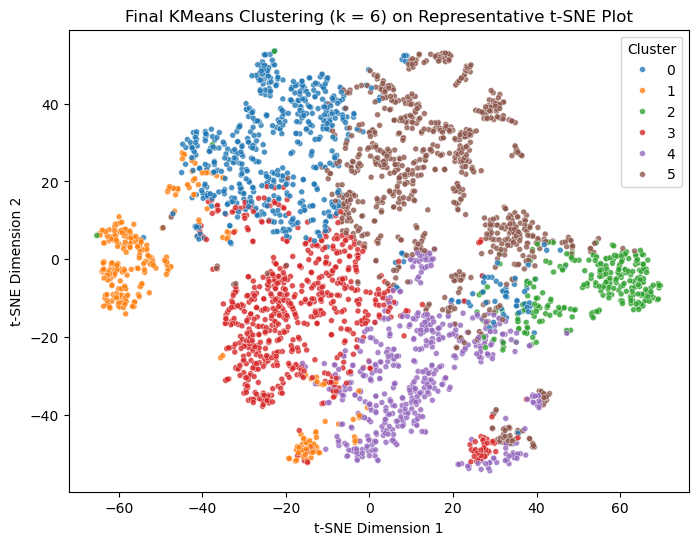

In [21]:
kmeans_final = KMeans(n_clusters=6, random_state=437, n_init=10)
final_labels = kmeans_final.fit_predict(X)
df["kmeans_final"] = final_labels

df_tsne_final = tsne_results[(30, 33)].copy()

df_tsne_final["cluster"] = final_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_tsne_final,
    x="tsne_x",
    y="tsne_y",
    hue="cluster",
    palette="tab10",
    s=18,
    alpha=0.8
)

plt.title("Final KMeans Clustering (k = 6) on Representative t-SNE Plot")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster")
plt.show()

- Based on the parameter tuning analyses, we selected the KMeans clustering with k = 6 as our primary final solution. This model provided strong evidence across multiple criteria, including t-SNE corroboration, cluster-sorted similarity matrices, and overall interpretability.

- The final t-SNE visualization shows that the six clusters align well with several naturally separated regions of the beer profile map. The solution captures major beer groupings while avoiding excessive fragmentation into overly small clusters. This suggests that the model successfully identifies broad inherent beer profile segments while still preserving meaningful subgroup structure.

- Cluster size counts indicate that the solution includes both larger mainstream beer groups and smaller niche segments, which is consistent with expectations for a diverse beer dataset. Overall, the k = 6 KMeans clustering provides a strong and interpretable representation of the underlying clustering structure.

# Review Analysis (consumer-rate based)

In [22]:
review_cols = [
    'review_aroma',
    'review_appearance',
    'review_palate',
    'review_taste',
    'review_overall',
    'number_of_reviews'
]

review_summary = df.groupby("kmeans_final")[review_cols].mean()
review_summary.head()

,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
kmeans_final,,,,,,
0,3.526538,3.710041,3.642668,3.644227,3.780792,187.807131
1,3.978772,4.037088,3.946110,4.012932,3.963906,483.142857
2,3.922400,3.886720,3.853094,3.932114,3.916055,211.563433
3,3.737517,3.884437,3.735083,3.813605,3.848004,211.543155
4,3.880180,3.896628,3.847255,3.913760,3.821007,282.031250


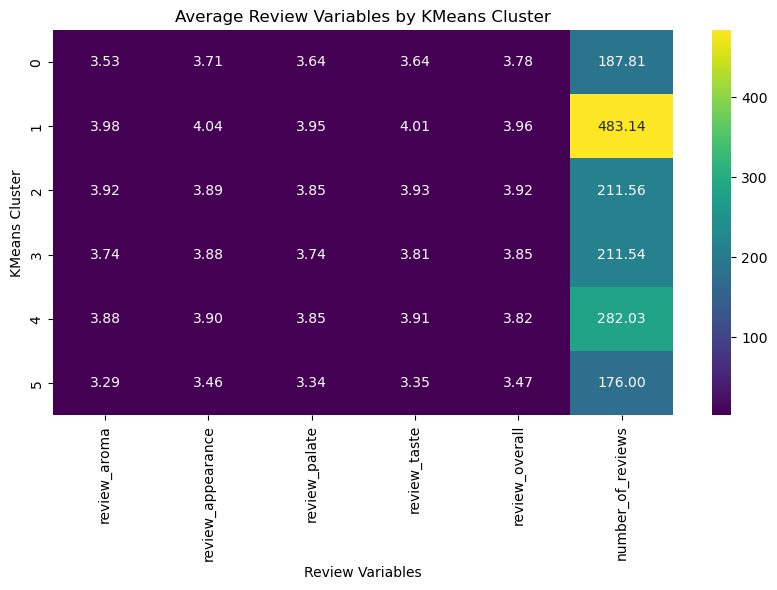

In [23]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    review_summary,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Average Review Variables by KMeans Cluster")
plt.xlabel("Review Variables")
plt.ylabel("KMeans Cluster")
plt.show()

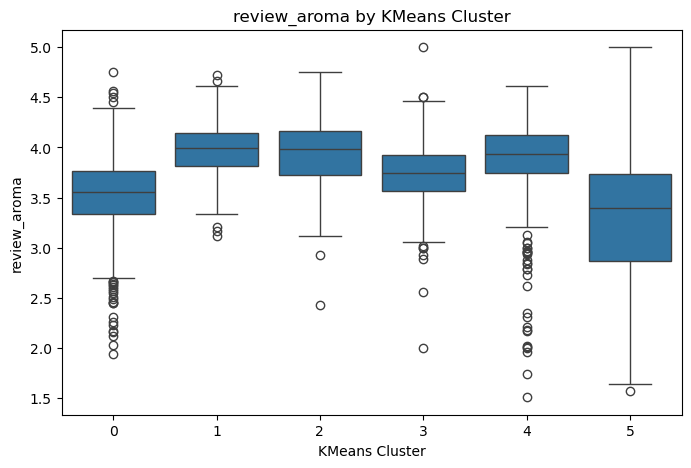

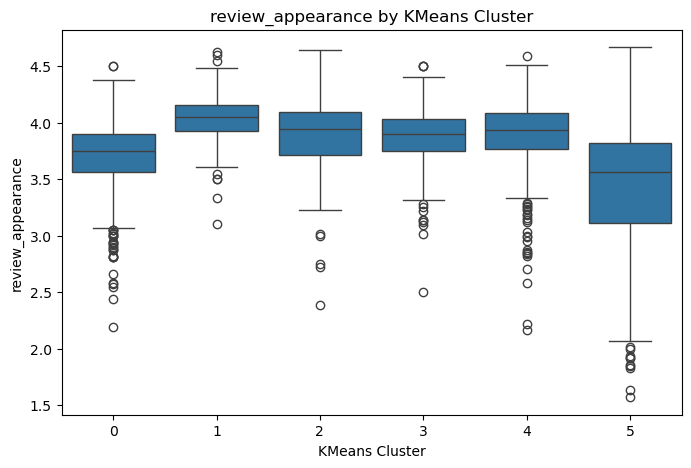

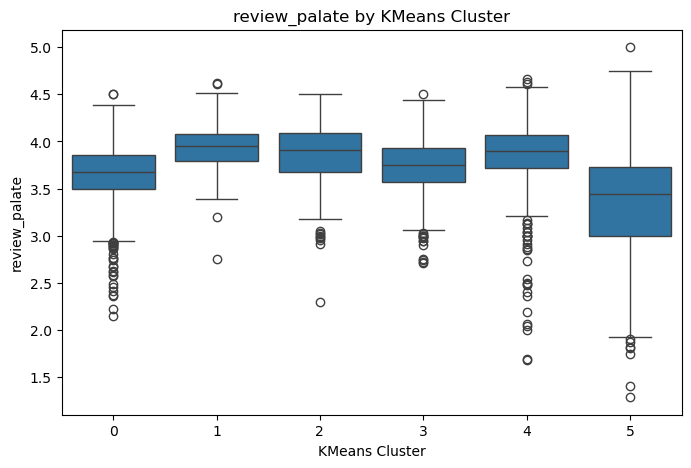

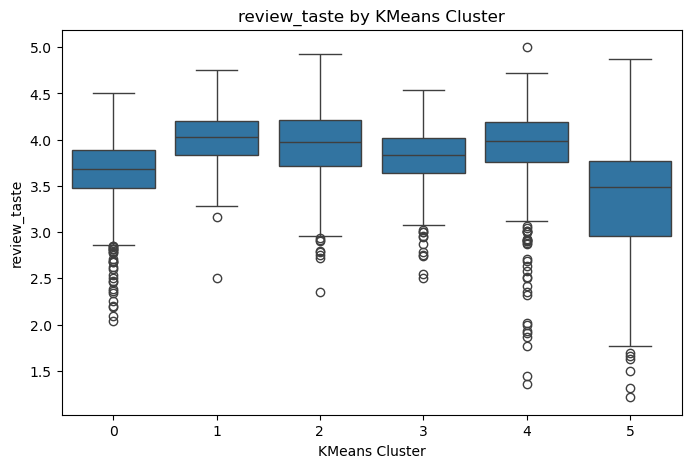

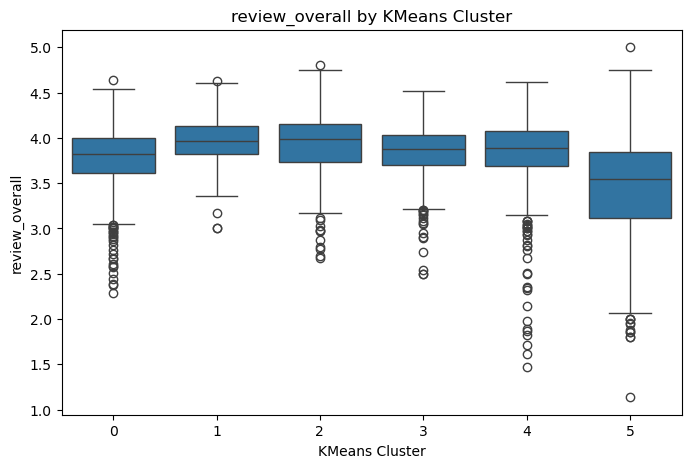

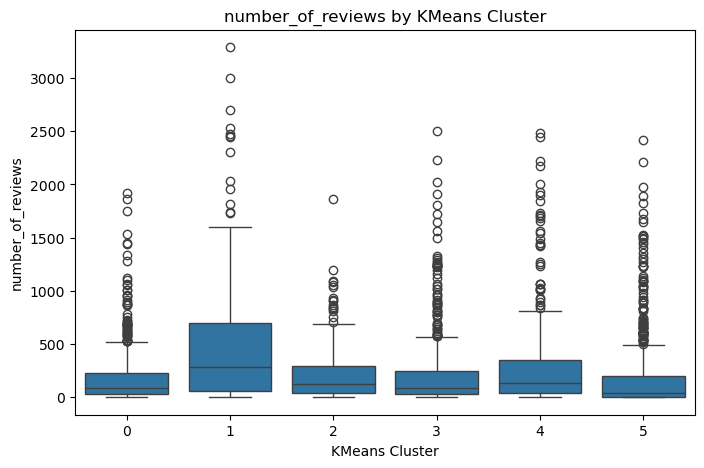

In [24]:
for col in review_cols:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="kmeans_final",
        y=col
    )
    
    plt.xlabel("KMeans Cluster")
    plt.ylabel(col)
    plt.title(f"{col} by KMeans Cluster")
    plt.show()

- ## Review Variable Interpretation by Cluster

Although the KMeans clustering was created using beer product attributes rather than review scores, the resulting clusters show meaningful differences in consumer ratings.

- Clusters 1, 2, and 4 consistently achieved higher median scores in aroma, appearance, palate, taste, and overall rating. This suggests that these clusters represent beer styles that are generally more preferred by consumers.

- Cluster 1 appears especially strong in overall rating, indicating a potentially premium or highly satisfying product segment.

- Cluster 5 showed the lowest review scores across nearly all categories and also displayed wider variability, suggesting lower consistency in consumer satisfaction or a more niche market segment.

- Clusters 0 and 3 had moderate review scores, representing more average or mainstream beer groups.

- The number of reviews also differed across clusters. Cluster 1 had the largest review counts, suggesting that this cluster may contain more popular, widely recognized, or highly distributed beers.

- Overall, these findings indicate that the clustering based on beer characteristics captures meaningful structure that is also reflected in consumer evaluations.